## Project Assignment: Classification and Evaluation

### 1. Dataset Selection

- Identify the dataset you will use for this project (this was partially completed in Project 2).
- Refer to the guide in the **Resources** folder on Blackboard for instructions on copying the dataset into **NETLAB**.
- Use a curated dataset with pre-processed features (e.g., a `.csv` file).
- The dataset must include a **target class label** (typically the last column).

In [ ]:
import pandas as pd

benign_path = "Datasense\\benign_samples_10sec.csv"
attack_path = "Datasense\\attack_samples_10sec.csv"

benign_df = pd.read_csv(benign_path)
attack_df = pd.read_csv(attack_path)

print("Benign shape:", benign_df.shape)
print("Attack shape:", attack_df.shape)

benign_df.head()
attack_df.head()

Benign shape: (13680, 94)
Attack shape: (16350, 94)


,device_name,device_mac,label_full,label1,label2,label3,label4,timestamp,timestamp_start,timestamp_end,...,network_time-delta_min,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation
0,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:10.709000Z_2025-01-23T15:31:2...,2025-01-23T15:31:10.709000Z,2025-01-23T15:31:20.709000Z,...,2.600000e-08,0.000042,64.0,64.0,64.0,0.0,17587.532313,64240.0,0.0,28377.701703
1,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:15.709000Z_2025-01-23T15:31:2...,2025-01-23T15:31:15.709000Z,2025-01-23T15:31:25.709000Z,...,2.500000e-08,0.000041,64.0,64.0,64.0,0.0,17259.307890,64240.0,0.0,28201.477525
2,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:20.709000Z_2025-01-23T15:31:3...,2025-01-23T15:31:20.709000Z,2025-01-23T15:31:30.709000Z,...,2.500000e-08,0.000041,64.0,64.0,64.0,0.0,17185.878307,64240.0,0.0,28161.438527
3,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:25.709000Z_2025-01-23T15:31:3...,2025-01-23T15:31:25.709000Z,2025-01-23T15:31:35.709000Z,...,2.500000e-08,0.000041,64.0,64.0,64.0,0.0,16750.718465,64240.0,0.0,27918.422488
4,edge1,dc:a6:32:dc:27:d4,attack_ddos_syn-flood-port-80_edge1,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T15:31:30.709000Z_2025-01-23T15:31:4...,2025-01-23T15:31:30.709000Z,2025-01-23T15:31:40.709000Z,...,2.600000e-08,0.000041,64.0,64.0,64.0,0.0,16673.446073,64240.0,0.0,27874.486393


In [4]:
benign_df = benign_df.copy()
attack_df = attack_df.copy()

benign_df["target"] = 0   # benign
attack_df["target"] = 1   # attack

df = pd.concat([benign_df, attack_df], ignore_index=True)

# shuffle rows so it's not all benign then all attack
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Combined shape:", df.shape)
print(df["target"].value_counts())

df.head()


Combined shape: (30030, 95)
target
1    16350
0    13680
Name: count, dtype: int64


,device_name,device_mac,label_full,label1,label2,label3,label4,timestamp,timestamp_start,timestamp_end,...,network_time-delta_std_deviation,network_ttl_avg,network_ttl_max,network_ttl_min,network_ttl_std_deviation,network_window-size_avg,network_window-size_max,network_window-size_min,network_window-size_std_deviation,target
0,wisenet-camera,00:09:18:6d:73:b9,attack_ddos_syn-flood-port-80_wisenet-camera,attack,ddos,syn-flood-port-80,ddos_syn-flood-port-80,2025-01-23T16:48:01.496000Z_2025-01-23T16:48:1...,2025-01-23T16:48:01.496000Z,2025-01-23T16:48:11.496000Z,...,0.000049,64.000000,64.0,64.0,0.000000,522.212844,29200.0,0.0,546.045134,1
1,proximity-collision-sensor,08:b6:1f:82:ef:30,attack_recon_host-disc-udp-ping_whole-network,attack,recon,host-disc-udp-ping,recon_host-disc-udp-ping,2025-01-15T13:23:11.175000Z_2025-01-15T13:23:2...,2025-01-15T13:23:11.175000Z,2025-01-15T13:23:21.175000Z,...,0.004002,151.624625,255.0,37.0,103.177070,3749.819820,64059.0,1024.0,5243.255357,1
2,edge1,dc:a6:32:dc:27:d4,attack_web_sql-injection-blind_edge1,attack,web,sql-injection-blind,web_sql-injection-blind,2025-01-28T20:33:13.676000Z_2025-01-28T20:33:2...,2025-01-28T20:33:13.676000Z,2025-01-28T20:33:23.676000Z,...,0.004366,63.504464,64.0,63.0,0.499980,11430.758929,65160.0,477.0,24129.125502,1
3,light-sensor,8c:aa:b5:8a:a9:b4,benign_whole-network3,benign,benign,benign,benign,2025-09-09T15:06:00.400000Z_2025-09-09T15:06:1...,2025-09-09T15:06:00.400000Z,2025-09-09T15:06:10.400000Z,...,0.016483,157.279070,255.0,64.0,95.474172,35479.116279,64056.0,5540.0,29249.373000,0
4,plug-cameras-yi,50:02:91:10:ac:d8,attack_dos_http-flood-port-6668_plug-cameras-yi,attack,dos,http-flood-port-6668,dos_http-flood-port-6668,2025-01-17T18:04:20.758000Z_2025-01-17T18:04:3...,2025-01-17T18:04:20.758000Z,2025-01-17T18:04:30.758000Z,...,0.027356,176.352941,255.0,64.0,94.001215,27997.658824,64240.0,0.0,30355.226261,1


### 2. Feature Selection

- Select **five features** from your dataset to use in your analysis.
- You do **not** need to use a PCAP dataset or extract features using Zeek for this assignment.
- Ensure the selected features are relevant to the classification task.

In [5]:
feature_cols = [
    "network_packet-size_avg",
    "network_payload-length_avg",
    "network_time-delta_avg",
    "network_tcp-flags-syn_count",
    "network_fragmentation-score",
]

missing = [c for c in feature_cols if c not in df.columns]
print("Missing feature columns:", missing)

df[feature_cols + ["target"]].head()


Missing feature columns: []


,network_packet-size_avg,network_payload-length_avg,network_time-delta_avg,network_tcp-flags-syn_count,network_fragmentation-score,target
0,60.001228,0.000000,0.000009,1122872,0.0,1
1,60.310448,0.348348,0.000674,165,0.0,1
2,341.117787,273.923214,0.001788,572,0.0,1
3,71.166667,18.465116,0.008004,0,0.0,0
4,87.227273,26.117647,0.014915,20,0.0,1


In [6]:
for c in feature_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[feature_cols].dtypes


network_packet-size_avg        float64
network_payload-length_avg     float64
network_time-delta_avg         float64
network_tcp-flags-syn_count      int64
network_fragmentation-score    float64
dtype: object

In [7]:
df[feature_cols].isna().sum()


network_packet-size_avg        0
network_payload-length_avg     0
network_time-delta_avg         0
network_tcp-flags-syn_count    0
network_fragmentation-score    0
dtype: int64

In [8]:
X = df[feature_cols].copy()
y = df["target"].astype(int).copy()

print("X shape:", X.shape)
print("y counts:\n", y.value_counts())


X shape: (30030, 5)
y counts:
 target
1    16350
0    13680
Name: count, dtype: int64


### 3. Model Training

- Perform a **70%–30% train-test split** on your dataset.
- Train **three different classification models** on the training set.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("\nTrain class counts:\n", y_train.value_counts())
print("\nTest class counts:\n", y_test.value_counts())

Train shape: (21021, 5)
Test shape : (9009, 5)

Train class counts:
 target
1    11445
0     9576
Name: count, dtype: int64

Test class counts:
 target
1    4905
0    4104
Name: count, dtype: int64


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape :", X_test_scaled.shape)


Scaled train shape: (21021, 5)
Scaled test shape : (9009, 5)


#### RANDOM FOREST

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest trained.")


Random Forest trained.


In [12]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, confusion_matrix
)

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, pos_label=1, zero_division=0)
rec_rf = recall_score(y_test, y_pred_rf, pos_label=1, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, pos_label=1, zero_division=0)
mcc_rf = matthews_corrcoef(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("=== Random Forest ===")
print("Accuracy :", acc_rf)
print("Precision:", prec_rf)
print("Recall   :", rec_rf)
print("F1-score :", f1_rf)
print("MCC      :", mcc_rf)
print("\nConfusion Matrix [[TN FP],[FN TP]]:\n", cm_rf)


=== Random Forest ===
Accuracy : 0.9524919524919525
Precision: 0.9612610756233257
Recall   : 0.9510703363914373
F1-score : 0.9561385529821684
MCC      : 0.9043868829695003

Confusion Matrix [[TN FP],[FN TP]]:
 [[3916  188]
 [ 240 4665]]


#### SUPPORT VECTOR MACHINE (SVM)

In [13]:
from sklearn.svm import SVC

svm = SVC(
    kernel="rbf",
    probability=True,     # needed for ROC curve probabilities
    class_weight="balanced",
    random_state=42
)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

print("SVM (RBF) trained.")


SVM (RBF) trained.


In [14]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, confusion_matrix
)

acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm, pos_label=1, zero_division=0)
rec_svm = recall_score(y_test, y_pred_svm, pos_label=1, zero_division=0)
f1_svm = f1_score(y_test, y_pred_svm, pos_label=1, zero_division=0)
mcc_svm = matthews_corrcoef(y_test, y_pred_svm)
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("=== SVM (RBF) ===")
print("Accuracy :", acc_svm)
print("Precision:", prec_svm)
print("Recall   :", rec_svm)
print("F1-score :", f1_svm)
print("MCC      :", mcc_svm)
print("\nConfusion Matrix [[TN FP],[FN TP]]:\n", cm_svm)


=== SVM (RBF) ===
Accuracy : 0.8609168609168609
Precision: 0.9376797698945349
Recall   : 0.7975535168195719
F1-score : 0.8619587969593479
MCC      : 0.7332934011618636

Confusion Matrix [[TN FP],[FN TP]]:
 [[3844  260]
 [ 993 3912]]


#### Multi-Layer Perceptron (MLP)

In [15]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # two hidden layers
    max_iter=500,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

y_pred_mlp = mlp.predict(X_test_scaled)
y_prob_mlp = mlp.predict_proba(X_test_scaled)[:, 1]

print("MLP (Neural Network) trained.")


MLP (Neural Network) trained.


In [16]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, confusion_matrix
)

acc_mlp = accuracy_score(y_test, y_pred_mlp)
prec_mlp = precision_score(y_test, y_pred_mlp, pos_label=1, zero_division=0)
rec_mlp = recall_score(y_test, y_pred_mlp, pos_label=1, zero_division=0)
f1_mlp = f1_score(y_test, y_pred_mlp, pos_label=1, zero_division=0)
mcc_mlp = matthews_corrcoef(y_test, y_pred_mlp)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

print("=== MLP (Neural Network) ===")
print("Accuracy :", acc_mlp)
print("Precision:", prec_mlp)
print("Recall   :", rec_mlp)
print("F1-score :", f1_mlp)
print("MCC      :", mcc_mlp)
print("\nConfusion Matrix [[TN FP],[FN TP]]:\n", cm_mlp)


=== MLP (Neural Network) ===
Accuracy : 0.9297369297369298
Precision: 0.9554371002132196
Recall   : 0.9135575942915393
F1-score : 0.9340281396560709
MCC      : 0.8599447632910516

Confusion Matrix [[TN FP],[FN TP]]:
 [[3895  209]
 [ 424 4481]]


### 4. Model Evaluation

Evaluate the performance of all three models using the following metrics:

- Accuracy  
- Precision  
- Recall  
- F1-score  
- Matthews Correlation Coefficient (MCC)

In [17]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Random Forest", "SVM (RBF)", "MLP"],
    "Accuracy": [acc_rf, acc_svm, acc_mlp],
    "Precision": [prec_rf, prec_svm, prec_mlp],
    "Recall": [rec_rf, rec_svm, rec_mlp],
    "F1-score": [f1_rf, f1_svm, f1_mlp],
    "MCC": [mcc_rf, mcc_svm, mcc_mlp],
})

results


,Model,Accuracy,Precision,Recall,F1-score,MCC
0,Random Forest,0.952492,0.961261,0.951070,0.956139,0.904387
1,SVM (RBF),0.860917,0.937680,0.797554,0.861959,0.733293
2,MLP,0.929737,0.955437,0.913558,0.934028,0.859945


### 5. ROC Curve Comparison

- Plot the **ROC curves** for all three models on a single graph.
- Based on the results, determine which model performed the best and justify your answer.

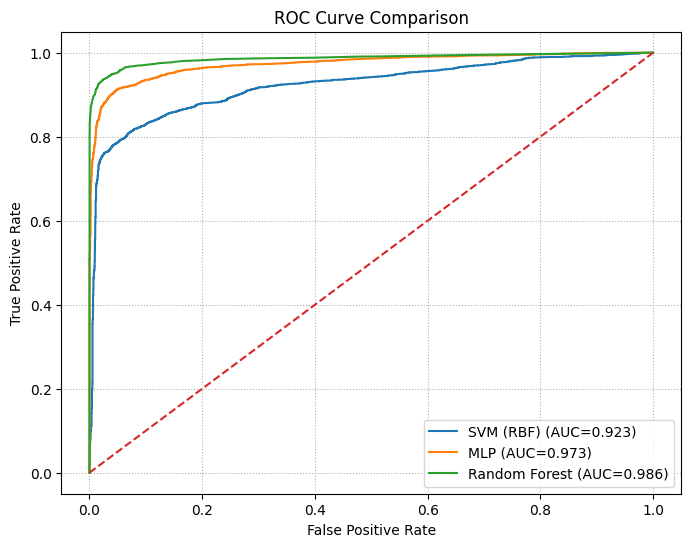

AUC values:
SVM: 0.9226570432764434
MLP: 0.9734484444205995
RF : 0.9863621528336642


In [18]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# AUC scores
auc_rf = roc_auc_score(y_test, y_prob_rf)
auc_svm = roc_auc_score(y_test, y_prob_svm)
auc_mlp = roc_auc_score(y_test, y_prob_mlp)

# ROC curve points
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_mlp, tpr_mlp, _ = roc_curve(y_test, y_prob_mlp)
plt.figure(figsize=(8, 6))

plt.plot(fpr_svm, tpr_svm, label=f"SVM (RBF) (AUC={auc_svm:.3f})")
plt.plot(fpr_mlp, tpr_mlp, label=f"MLP (AUC={auc_mlp:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.3f})")


plt.plot([0, 1], [0, 1], linestyle="--")  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True, linestyle=":")

plt.show()

print("AUC values:")
print("SVM:", auc_svm)
print("MLP:", auc_mlp)
print("RF :", auc_rf)



In [19]:
import pandas as pd

summary = pd.DataFrame({
    "Model": ["Random Forest", "SVM (RBF)", "MLP"],
    "ROC_AUC": [auc_rf, auc_svm, auc_mlp],
    "MCC": [ mcc_rf, mcc_svm, mcc_mlp],
    "F1-score": [ f1_rf, f1_svm, f1_mlp],
    "Recall": [ rec_rf, rec_svm, rec_mlp],
    "Precision": [ prec_rf, prec_svm, prec_mlp],
})

summary_sorted = summary.sort_values(by=["ROC_AUC", "MCC"], ascending=False)

summary_sorted

,Model,ROC_AUC,MCC,F1-score,Recall,Precision
0,Random Forest,0.986362,0.904387,0.956139,0.951070,0.961261
2,MLP,0.973448,0.859945,0.934028,0.913558,0.955437
1,SVM (RBF),0.922657,0.733293,0.861959,0.797554,0.937680


In [20]:
best = summary_sorted.iloc[0]
print("Best model by ROC_AUC (tie-breaker MCC):")
print(best)


Best model by ROC_AUC (tie-breaker MCC):
Model        Random Forest
ROC_AUC           0.986362
MCC               0.904387
F1-score          0.956139
Recall             0.95107
Precision         0.961261
Name: 0, dtype: object
